# 03 · Model Tuning & Final Evaluation

**Goal:**
1. Vectorize once using the best config from notebook 02.
2. `GridSearchCV` (5-fold, `scoring=f1_macro`) for all 3 models; each CV candidate gets its own nested MLflow run.
3. Retrain each best config on train+val combined using `Experiment.retrain_on()`.
4. **Final evaluation** on the held-out test set — called exactly once per model.
5. Summary table, confusion matrices, and classification reports for all 3 models.

**MLflow tags:**
- `study=model_tuning_gs` — individual CV candidate runs  
- `study=final`           — retrained models evaluated on test

> **The test set is used ONLY in section 5 (evaluate_on_test).**

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow

from sklearn.model_selection import GridSearchCV

from experiments.experiment import Experiment
from models.logistic_regression import LogisticRegressionModel
from models.svm import SVMModel
from models.random_forest import RandomForestModel
from vectorization.tfidf import TfidfVectorizerWrapper
from evaluation.metrics import ClassificationMetrics

c:\Users\Iva\AppData\Local\pypoetry\Cache\virtualenvs\imdb-sentiment-classification-S-I29JL4-py3.11\Lib\site-packages\pydantic\_internal\_config.py:386: UserWarning: Valid config keys have changed in V2:
* 'schema_extra' has been renamed to 'json_schema_extra'
  warnings.warn(message, UserWarning)


In [2]:
with open('../results/splits.pkl', 'rb') as f:
    splits = pickle.load(f)

df_train = splits['train']
df_val   = splits['val']
df_test  = splits['test']

with open('../results/best_vectorizer_config.pkl', 'rb') as f:
    vec_config = pickle.load(f)

print('Best vectorizer config:', vec_config)
print(f'Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')

Best vectorizer config: {'vectorizer_class': 'TfidfVectorizerWrapper', 'ngram_range': (1, 2), 'min_df': 5}
Train: 40,000 | Val: 5,000 | Test: 5,000


In [4]:
shared_vectorizer = TfidfVectorizerWrapper(
    ngram_range=vec_config['ngram_range'],
    min_df=vec_config['min_df'],
)

X_train = shared_vectorizer.fit_transform(df_train)
X_val   = shared_vectorizer.transform(df_val)

y_train = df_train['sentiment'].values
y_val   = df_val['sentiment'].values

print(f'X_train shape: {X_train.shape}')
print(f'X_val   shape: {X_val.shape}')

X_train shape: (40000, 139992)
X_val   shape: (5000, 139992)


In [5]:
PROJECT_ROOT = os.path.abspath('..')
mlflow.set_tracking_uri(f'file:///{PROJECT_ROOT}/mlruns'.replace('\\', '/'))
mlflow.set_experiment('imdb-sentiment')

<Experiment: artifact_location='file:///c:/Users/Iva/Desktop/imdb-sentiment-classification/mlruns/397932824360539574', creation_time=1779195973368, experiment_id='397932824360539574', last_update_time=1779195973368, lifecycle_stage='active', name='imdb-sentiment', tags={}>

gridsearch

In [ ]:
def run_grid_search(
    model_instance,
    param_grid: dict,
    X_train,
    y_train,
    X_val,
    y_val,
    model_name: str,
):
   
    gs = GridSearchCV(
        estimator=model_instance,
        param_grid=param_grid,
        scoring='f1_macro',
        cv=5,
        n_jobs=-1,
        refit=True,
        verbose=1,
        return_train_score=False,
    )
    gs.fit(X_train, y_train)

    with mlflow.start_run(run_name=f'{model_name}_gs', tags={'study': 'model_tuning_gs'}):
        for i, params in enumerate(gs.cv_results_['params']):
            mean_cv  = gs.cv_results_['mean_test_score'][i]
            std_cv   = gs.cv_results_['std_test_score'][i]
            with mlflow.start_run(run_name=f'{model_name}_candidate_{i}', nested=True,
                                  tags={'study': 'model_tuning_gs'}):
                mlflow.log_params({'model': model_name, **params})
                mlflow.log_metrics({'mean_cv_f1': mean_cv, 'std_cv_f1': std_cv})

    y_pred_val = gs.best_estimator_.predict(X_val)
    val_metrics = ClassificationMetrics(
        y_true=y_val,
        y_pred=y_pred_val,
        n_features=X_val.shape[1],
    )

    best_cv_f1  = gs.best_score_
    best_cv_std = gs.cv_results_['std_test_score'][gs.best_index_]

    with mlflow.start_run(run_name=f'{model_name}_best_config',
                          tags={'study': 'model_tuning_gs'}):
        mlflow.log_params({'model': model_name, **gs.best_params_})
        mlflow.log_metrics({
            'best_cv_f1':  best_cv_f1,
            'best_cv_std': best_cv_std,
            'val_f1':      val_metrics.f1,
            'val_accuracy': val_metrics.accuracy,
            'val_precision': val_metrics.precision,
            'val_recall':    val_metrics.recall,
        })

    print(f'{model_name}: best_params={gs.best_params_}  '
          f'cv_f1={best_cv_f1:.4f}  val_f1={val_metrics.f1:.4f}')
    return gs, val_metrics

In [7]:
gs_lr, val_metrics_lr = run_grid_search(
    model_instance=LogisticRegressionModel(),
    param_grid={'C': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]},
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    model_name='LogisticRegression',
)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


2026/05/19 22:48:58 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



LogisticRegression: best_params={'C': 5.0}  cv_f1=0.9005  val_f1=0.9091


In [8]:
gs_svm, val_metrics_svm = run_grid_search(
    model_instance=SVMModel(),
    param_grid={'C': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]},
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    model_name='SVM',
)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
SVM: best_params={'C': 0.5}  cv_f1=0.9020  val_f1=0.9131


In [9]:
gs_rf, val_metrics_rf = run_grid_search(
    model_instance=RandomForestModel(),
    param_grid={
        'n_estimators': [50, 100, 200],
        'max_depth':    [None, 10, 20, 50],
    },
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    model_name='RandomForest',
)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
RandomForest: best_params={'max_depth': None, 'n_estimators': 200}  cv_f1=0.8656  val_f1=0.8718


In [10]:
def make_best_experiment(gs, model_class, vec_config, model_name: str) -> Experiment:
    """Build an Experiment pre-loaded with the best hyperparams from gs."""
    best_model = model_class(**gs.best_params_)
    best_vec   = TfidfVectorizerWrapper(
        ngram_range=vec_config['ngram_range'],
        min_df=vec_config['min_df'],
    )
    return Experiment(
        model=best_model,
        vectorizer=best_vec,
        run_name=model_name,
    )

In [13]:
FINAL_TAGS = {'study': 'final'}

best_lr_exp = make_best_experiment(gs_lr, LogisticRegressionModel, vec_config, 'LogisticRegression')
best_lr_final = best_lr_exp.retrain_on(df_train, df_val).evaluate_on_test(
    df_test,
    extra_metrics={
        'best_cv_f1':    gs_lr.best_score_,
        'best_cv_std':   gs_lr.cv_results_['std_test_score'][gs_lr.best_index_],
        'val_f1':        val_metrics_lr.f1,
        'val_accuracy':  val_metrics_lr.accuracy,
        'val_precision': val_metrics_lr.precision,
        'val_recall':    val_metrics_lr.recall,
    },
    tags=FINAL_TAGS,
)
print('LogisticRegression — final evaluation complete')

LogisticRegression — final evaluation complete


In [14]:
best_svm_exp = make_best_experiment(gs_svm, SVMModel, vec_config, 'SVM')
best_svm_final = best_svm_exp.retrain_on(df_train, df_val).evaluate_on_test(
    df_test,
    extra_metrics={
        'best_cv_f1':    gs_svm.best_score_,
        'best_cv_std':   gs_svm.cv_results_['std_test_score'][gs_svm.best_index_],
        'val_f1':        val_metrics_svm.f1,
        'val_accuracy':  val_metrics_svm.accuracy,
        'val_precision': val_metrics_svm.precision,
        'val_recall':    val_metrics_svm.recall,
    },
    tags=FINAL_TAGS,
)
print('SVM — final evaluation complete')

SVM — final evaluation complete


In [15]:
best_rf_exp = make_best_experiment(gs_rf, RandomForestModel, vec_config, 'RandomForest')
best_rf_final = best_rf_exp.retrain_on(df_train, df_val).evaluate_on_test(
    df_test,
    extra_metrics={
        'best_cv_f1':    gs_rf.best_score_,
        'best_cv_std':   gs_rf.cv_results_['std_test_score'][gs_rf.best_index_],
        'val_f1':        val_metrics_rf.f1,
        'val_accuracy':  val_metrics_rf.accuracy,
        'val_precision': val_metrics_rf.precision,
        'val_recall':    val_metrics_rf.recall,
    },
    tags=FINAL_TAGS,
)
print('RandomForest — final evaluation complete')

RandomForest — final evaluation complete


In [16]:
def get_test_metrics(retrained_exp: Experiment, df_test: pd.DataFrame) -> ClassificationMetrics:
    """Re-predict on test using the retrained experiment (for local plotting)."""
    import time
    X_test = retrained_exp.vectorizer.transform(df_test)
    t0 = time.perf_counter()
    y_pred = retrained_exp.model.predict(X_test)
    inf_time = time.perf_counter() - t0
    return ClassificationMetrics(
        y_true=df_test['sentiment'],
        y_pred=y_pred,
        inference_time=inf_time,
        n_features=X_test.shape[1],
    )

test_metrics_lr  = get_test_metrics(best_lr_final,  df_test)
test_metrics_svm = get_test_metrics(best_svm_final, df_test)
test_metrics_rf  = get_test_metrics(best_rf_final,  df_test)

summary = pd.DataFrame([
    {
        'model':         'LogisticRegression',
        'best_params':   gs_lr.best_params_,
        'cv_f1':         round(gs_lr.best_score_, 4),
        'val_f1':        round(val_metrics_lr.f1, 4),
        'test_f1':       round(test_metrics_lr.f1, 4),
        'test_accuracy': round(test_metrics_lr.accuracy, 4),
        'inference_ms':  round(test_metrics_lr.inference_time * 1000, 1),
    },
    {
        'model':         'SVM',
        'best_params':   gs_svm.best_params_,
        'cv_f1':         round(gs_svm.best_score_, 4),
        'val_f1':        round(val_metrics_svm.f1, 4),
        'test_f1':       round(test_metrics_svm.f1, 4),
        'test_accuracy': round(test_metrics_svm.accuracy, 4),
        'inference_ms':  round(test_metrics_svm.inference_time * 1000, 1),
    },
    {
        'model':         'RandomForest',
        'best_params':   gs_rf.best_params_,
        'cv_f1':         round(gs_rf.best_score_, 4),
        'val_f1':        round(val_metrics_rf.f1, 4),
        'test_f1':       round(test_metrics_rf.f1, 4),
        'test_accuracy': round(test_metrics_rf.accuracy, 4),
        'inference_ms':  round(test_metrics_rf.inference_time * 1000, 1),
    },
])
summary.sort_values('test_f1', ascending=False, inplace=True)
summary

,model,best_params,cv_f1,val_f1,test_f1,test_accuracy,inference_ms
1,SVM,{'C': 0.5},0.9020,0.9131,0.9073,0.9072,3.5
0,LogisticRegression,{'C': 5.0},0.9005,0.9091,0.9067,0.9066,6.8
2,RandomForest,"{'max_depth': None, 'n_estimators': 200}",0.8656,0.8718,0.8734,0.8744,527.3


### CV F1 vs Val F1 vs Test F1

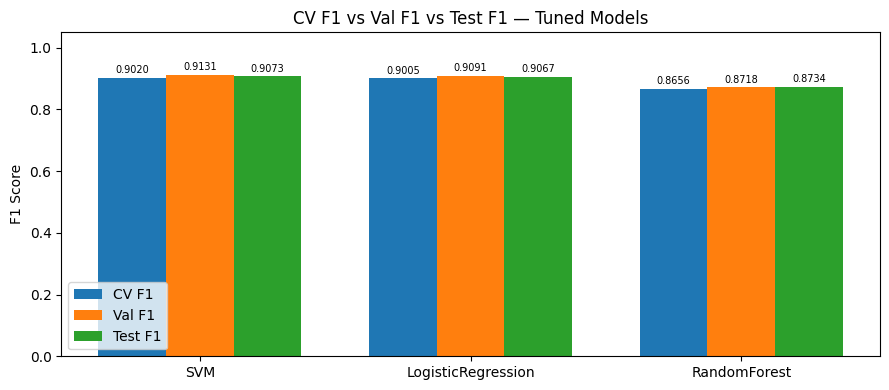

In [17]:
models = summary['model'].tolist()
x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 4))
for i, (col, label) in enumerate([('cv_f1', 'CV F1'), ('val_f1', 'Val F1'), ('test_f1', 'Test F1')]):
    vals = summary[col].tolist()
    bars = ax.bar(x + (i - 1) * width, vals, width, label=label)
    ax.bar_label(bars, fmt='%.4f', padding=2, fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.05)
ax.set_ylabel('F1 Score')
ax.set_title('CV F1 vs Val F1 vs Test F1 - Tuned Models')
ax.legend()
plt.tight_layout()
plt.show()

### matrice konfuzije na test skupu

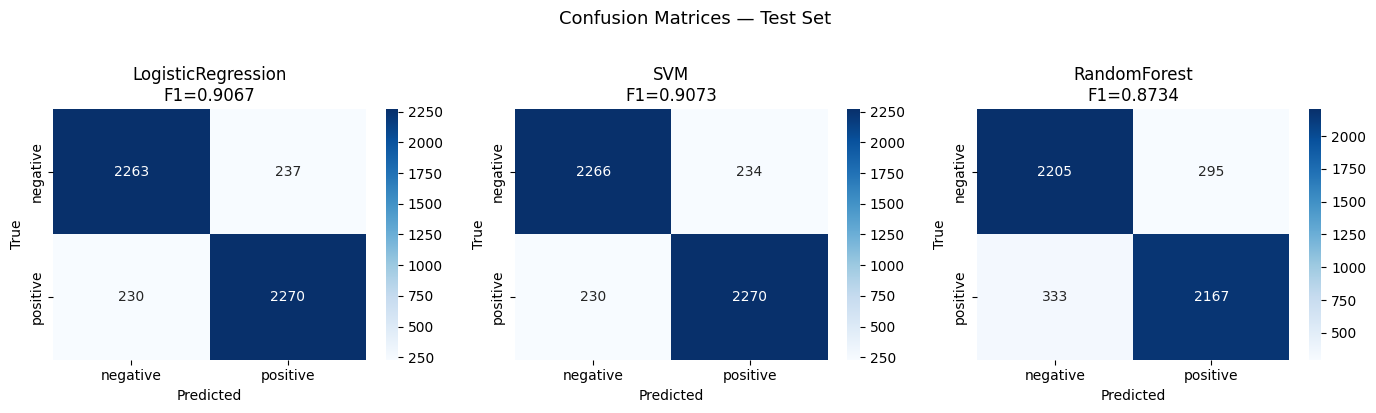

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (model_name, metrics) in zip(axes, [
    ('LogisticRegression', test_metrics_lr),
    ('SVM',                test_metrics_svm),
    ('RandomForest',       test_metrics_rf),
]):
    sns.heatmap(
        metrics.confusion_matrix,
        annot=True, fmt='d', cmap='Blues',
        xticklabels=['negative', 'positive'],
        yticklabels=['negative', 'positive'],
        ax=ax,
    )
    ax.set_title(f'{model_name}\nF1={metrics.f1:.4f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle('Confusion Matrices — Test Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [19]:
for model_name, metrics in [
    ('LogisticRegression', test_metrics_lr),
    ('SVM',                test_metrics_svm),
    ('RandomForest',       test_metrics_rf),
]:
    print(f'═══ {model_name} — Test Set ═══')
    print(metrics.report())
    print()

═══ LogisticRegression — Test Set ═══
              precision    recall  f1-score   support

    negative       0.91      0.91      0.91      2500
    positive       0.91      0.91      0.91      2500

    accuracy                           0.91      5000
   macro avg       0.91      0.91      0.91      5000
weighted avg       0.91      0.91      0.91      5000


═══ SVM — Test Set ═══
              precision    recall  f1-score   support

    negative       0.91      0.91      0.91      2500
    positive       0.91      0.91      0.91      2500

    accuracy                           0.91      5000
   macro avg       0.91      0.91      0.91      5000
weighted avg       0.91      0.91      0.91      5000


═══ RandomForest — Test Set ═══
              precision    recall  f1-score   support

    negative       0.87      0.88      0.88      2500
    positive       0.88      0.87      0.87      2500

    accuracy                           0.87      5000
   macro avg       0.87      0.87